<center>

# [Компьютерное зрение](http://rairi.ru/wiki/index.php/%D0%9A%D0%BE%D0%BC%D0%BF%D1%8C%D1%8E%D1%82%D0%B5%D1%80%D0%BD%D0%BE%D0%B5_%D0%B7%D1%80%D0%B5%D0%BD%D0%B8%D0%B5)

## <center> Семинар 12 - MinkowskiEngine

<a target="_blank" href="https://colab.research.google.com/github/alexmelekhin/cv_course_2023/blob/main/seminars/seminar_12/Seminar_12.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

***

# Установка MinkowskiEngine в Google Colab

При желании установить локально или где-либо еще - обращайтесь к инструкциям в репозитории: https://github.com/NVIDIA/MinkowskiEngine 

In [1]:
# вам потребуется GPU, проверьте ее наличие
!nvidia-smi

Sat May 16 15:01:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# !pip install torch==1.13.1 torchvision==0.14.1

In [3]:
!pip install ninja

In [4]:
# %%
import sys
import torch

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("torch.cuda.is_available():", torch.cuda.is_available())

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Torch: 2.10.0+cu128
torch.cuda.is_available(): True


In [5]:
# %%
!apt-get update -y
!apt-get install -y build-essential python3-dev libopenblas-dev ninja-build
!pip install -U ninja setuptools wheel

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:2 http://security.ubuntu.com/ubuntu jammy-security InRelease               
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]               
Hit:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease     
Hit:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease                 
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease               
Hit:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease                     
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease   
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,917 B in 2s (2,448 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repo

In [6]:
# %%
!pip uninstall -y MinkowskiEngine
!rm -rf /kaggle/working/MinkowskiEngine
!rm -rf /usr/local/lib/python*/dist-packages/MinkowskiEngine*
!rm -rf /usr/local/lib/python*/site-packages/MinkowskiEngine*
!rm -rf /usr/local/lib/python*/dist-packages/MinkowskiEngineBackend*
!rm -rf /usr/local/lib/python*/site-packages/MinkowskiEngineBackend*

In [7]:
# %%
!git clone --recursive https://github.com/NVIDIA/MinkowskiEngine.git /kaggle/working/MinkowskiEngine

%cd /kaggle/working/MinkowskiEngine

# CPU-only build. This is the important line.
!MAX_JOBS=2 python setup.py install --cpu_only --blas=openblas

%cd /kaggle/working

Cloning into '/kaggle/working/MinkowskiEngine'...
remote: Enumerating objects: 7355, done.
remote: Counting objects: 100% (1642/1642), done.
remote: Compressing objects: 100% (464/464), done.
remote: Total 7355 (delta 1226), reused 1178 (delta 1178), pack-reused 5713 (from 1)
Receiving objects: 100% (7355/7355), 14.64 MiB | 31.96 MiB/s, done.
Resolving deltas: 100% (5873/5873), done.
/kaggle/working/MinkowskiEngine
--------------------------------
| WARNING: CPU_ONLY build set  |
--------------------------------

Using BLAS=openblas
Using the default compiler
/usr/local/lib/python3.12/dist-packages/setuptools/dist.py:765: SetuptoolsDeprecationWarning: License classifiers are deprecated.
!!

        ********************************************************************************
        Please consider removing the following classifiers in favor of a SPDX license expression:

        License :: OSI Approved :: MIT License

        See https://packaging.python.org/en/latest/guides/writin

In [8]:
# %%
import torch
import MinkowskiEngine as ME

print("Torch:", torch.__version__)
print("MinkowskiEngine:", ME.__file__)

import MinkowskiEngineBackend._C as ME_BACKEND
print("MinkowskiEngine backend: OK")

try:
    ME.print_diagnostics()
except Exception as e:
    print("diagnostics failed but backend import is OK:", repr(e))

/usr/local/lib/python3.12/dist-packages/MinkowskiEngine/__init__.py:221: UserWarning: The MinkowskiEngine was compiled with CPU_ONLY flag. If you want to compile with CUDA support, make sure `torch.cuda.is_available()` is True when you install MinkowskiEngine.
  warnings.warn(


Torch: 2.10.0+cu128
MinkowskiEngine: /usr/local/lib/python3.12/dist-packages/MinkowskiEngine/__init__.py
MinkowskiEngine backend: OK
==========System==========
Linux-6.6.122+-x86_64-with-glibc2.35
DISTRIB_ID=Ubuntu
DISTRIB_RELEASE=22.04
DISTRIB_CODENAME=jammy
DISTRIB_DESCRIPTION="Ubuntu 22.04.5 LTS"
3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
==========Pytorch==========
2.10.0+cu128
torch.cuda.is_available(): True
==========NVIDIA-SMI==========
/opt/bin/nvidia-smi
Driver Version 580.105.08
CUDA Version 13.0
VBIOS Version 90.04.A7.00.01
Image Version G183.0200.00.02
GSP Firmware Version 580.105.08
==========NVCC==========
/usr/local/cuda/bin/nvcc
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
==========CC==========
/usr/bin/c++
c++ (Ubuntu 11.4.0-1ubuntu1~22.04.2) 11.4.0
Copyright (C) 2021 Free Software Foundation, Inc.
T

# ModelNet40-классификатор на MinkowskiEngine

Предлагается ознакомиться с оффициальными туториалами:

https://nvidia.github.io/MinkowskiEngine/demo/training.html

https://github.com/NVIDIA/MinkowskiEngine/blob/master/examples/training.py

https://nvidia.github.io/MinkowskiEngine/demo/modelnet40_classification.html


## Домашнее задание

Обучить простейшую модель классификации 3D объектов на датасете ModelNet40, воспользовавшись туториалом выше и кодом отсюда: https://github.com/NVIDIA/MinkowskiEngine/blob/master/examples/classification_modelnet40.py 

Вам предлагается обучить простейшую модель `minkfcnn` (аргумент `--network minkfcnn`).

В качестве отчета по заданию вам предлагается приложить результаты обучения (логи).

In [10]:
# %% [markdown]
# ## Домашнее задание: ModelNet40 + MinkowskiEngine (`minkfcnn`)
#
# Эти ячейки нужно добавить в конец ноутбука после установки и проверки `MinkowskiEngine`.

# %%
import os
import math
import time
import random
import zipfile
import hashlib
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

import MinkowskiEngine as ME

# %%
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

WORK_DIR = Path("/kaggle/working/minkfcnn_modelnet40_cpu")
WORK_DIR.mkdir(parents=True, exist_ok=True)

# Smaller CPU-safe setup
NUM_POINTS = 2048
VOXEL_SIZE = 0.04
MAX_VOXELS_PER_OBJECT = 1800

BATCH_SIZE = 24
NUM_WORKERS = 2
EPOCHS = 10
LR = 1e-3
WEIGHT_DECAY = 1e-4

MAX_TRAIN_SAMPLES = None
MAX_TEST_SAMPLES = None

CACHE_DIR = WORK_DIR / f"surface_cache_{NUM_POINTS}"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cpu")
print("device:", device)
print("work dir:", WORK_DIR)


try:
    ME.print_diagnostics()
except Exception:
    pass
print("work dir:", WORK_DIR)

# %%
def is_modelnet40_root(path: Path) -> bool:
    path = Path(path)
    if not path.exists() or not path.is_dir():
        return False
    class_dirs = [
        d for d in path.iterdir()
        if d.is_dir() and (d / "train").exists() and (d / "test").exists()
    ]
    return len(class_dirs) >= 40 and (path / "airplane").exists()


def find_existing_modelnet40_root() -> Path | None:
    candidates = [
        Path("/kaggle/working/ModelNet40"),
        Path("/kaggle/input/modelnet40/ModelNet40"),
        Path("/kaggle/input/modelnet40"),
        Path("/kaggle/input/modelnet40-princeton-3d-object-dataset/ModelNet40"),
        Path("/kaggle/input/modelnet40-princeton-3d-object-dataset"),
    ]

    for candidate in candidates:
        if is_modelnet40_root(candidate):
            return candidate

    input_root = Path("/kaggle/input")
    if input_root.exists():
        for airplane_dir in input_root.rglob("airplane"):
            root = airplane_dir.parent
            if is_modelnet40_root(root):
                return root
    return None


def download_modelnet40() -> Path:
    dst_root = Path("/kaggle/working/ModelNet40")
    if is_modelnet40_root(dst_root):
        return dst_root

    zip_path = Path("/kaggle/working/ModelNet40.zip")
    urls = [
        "http://modelnet.cs.princeton.edu/ModelNet40.zip",
        "https://modelnet.cs.princeton.edu/ModelNet40.zip",
    ]

    if not zip_path.exists():
        last_error = None
        for url in urls:
            try:
                print(f"Downloading ModelNet40 from {url}")
                urllib.request.urlretrieve(url, zip_path)
                break
            except Exception as error:
                last_error = error
                print(f"Failed: {error}")
        if not zip_path.exists():
            raise RuntimeError(
                "Не удалось скачать ModelNet40. "
                "Включите Internet в Kaggle или добавьте ModelNet40 как Kaggle Dataset."
            ) from last_error

    print("Extracting ModelNet40.zip ...")
    with zipfile.ZipFile(zip_path, "r") as archive:
        archive.extractall("/kaggle/working")

    if not is_modelnet40_root(dst_root):
        raise RuntimeError("Архив распакован, но папка /kaggle/working/ModelNet40 не найдена.")
    return dst_root


MODELNET_ROOT = find_existing_modelnet40_root()
if MODELNET_ROOT is None:
    MODELNET_ROOT = download_modelnet40()

print("MODELNET_ROOT:", MODELNET_ROOT)

CLASSES = sorted([
    d.name for d in MODELNET_ROOT.iterdir()
    if d.is_dir() and (d / "train").exists() and (d / "test").exists()
])
print("num classes:", len(CLASSES))
print("first classes:", CLASSES[:8])

# %%
def read_off(path: Path) -> tuple[np.ndarray, np.ndarray]:
    """Читает OFF-файл и возвращает вершины [V, 3] и треугольники [T, 3]."""
    with open(path, "r", encoding="utf-8", errors="ignore") as file:
        first = ""
        while first == "":
            first = file.readline().strip()

        if first == "OFF":
            counts = file.readline().strip()
        elif first.startswith("OFF"):
            counts = first[3:].strip()
        else:
            raise ValueError(f"Not an OFF file: {path}")

        while counts == "" or counts.startswith("#"):
            counts = file.readline().strip()

        n_vertices, n_faces, *_ = map(int, counts.split()[:3])

        vertices = []
        while len(vertices) < n_vertices:
            line = file.readline()
            if not line:
                break
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            vertices.append([float(x) for x in line.split()[:3]])

        faces = []
        for _ in range(n_faces):
            line = file.readline()
            if not line:
                break
            parts = line.strip().split()
            if not parts:
                continue

            n = int(parts[0])
            if n < 3:
                continue

            ids = [int(x) for x in parts[1:1 + n]]
            for j in range(1, n - 1):
                faces.append([ids[0], ids[j], ids[j + 1]])

    return np.asarray(vertices, dtype=np.float32), np.asarray(faces, dtype=np.int64)


def normalize_points(points: np.ndarray) -> np.ndarray:
    points = points.astype(np.float32)
    points = points - points.mean(axis=0, keepdims=True)
    scale = np.linalg.norm(points, axis=1).max()
    if scale > 0:
        points = points / scale
    return points.astype(np.float32)


def sample_points_from_mesh(
    vertices: np.ndarray,
    faces: np.ndarray,
    num_points: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """Сэмплирует точки с поверхности mesh. Если граней нет, сэмплирует вершины."""
    if len(vertices) == 0:
        return np.zeros((num_points, 3), dtype=np.float32)

    if len(faces) == 0:
        replace = len(vertices) < num_points
        idx = rng.choice(len(vertices), size=num_points, replace=replace)
        return normalize_points(vertices[idx])

    triangles = vertices[faces]
    v0, v1, v2 = triangles[:, 0], triangles[:, 1], triangles[:, 2]
    areas = 0.5 * np.linalg.norm(np.cross(v1 - v0, v2 - v0), axis=1)
    valid = areas > 1e-12

    if valid.sum() == 0:
        replace = len(vertices) < num_points
        idx = rng.choice(len(vertices), size=num_points, replace=replace)
        return normalize_points(vertices[idx])

    triangles = triangles[valid]
    areas = areas[valid]
    probs = areas / areas.sum()

    tri_idx = rng.choice(len(triangles), size=num_points, replace=True, p=probs)
    chosen = triangles[tri_idx]

    r1 = rng.random(num_points, dtype=np.float32)
    r2 = rng.random(num_points, dtype=np.float32)
    sqrt_r1 = np.sqrt(r1)

    sampled = (
        (1.0 - sqrt_r1)[:, None] * chosen[:, 0]
        + (sqrt_r1 * (1.0 - r2))[:, None] * chosen[:, 1]
        + (sqrt_r1 * r2)[:, None] * chosen[:, 2]
    )
    return normalize_points(sampled)


def augment_point_cloud(points: np.ndarray) -> np.ndarray:
    """Легкие аугментации для train: поворот вокруг z, scale, jitter."""
    theta = np.random.uniform(0.0, 2.0 * np.pi)
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    rot_z = np.array(
        [[cos_t, -sin_t, 0.0],
         [sin_t,  cos_t, 0.0],
         [0.0,    0.0,   1.0]],
        dtype=np.float32,
    )

    points = points @ rot_z.T
    points = points * np.random.uniform(0.90, 1.10)
    points = points + np.random.normal(0.0, 0.005, size=points.shape).astype(np.float32)
    return points.astype(np.float32)


class ModelNet40OFF(Dataset):
    def __init__(
        self,
        root: Path,
        split: str,
        classes: list[str],
        num_points: int,
        voxel_size: float,
        max_voxels: int,
        augment: bool,
        cache_dir: Path,
        max_samples: int | None = None,
    ):
        assert split in {"train", "test"}
        self.root = Path(root)
        self.split = split
        self.classes = classes
        self.class_to_idx = {name: idx for idx, name in enumerate(classes)}
        self.num_points = num_points
        self.voxel_size = voxel_size
        self.max_voxels = max_voxels
        self.augment = augment
        self.cache_dir = Path(cache_dir)

        samples = []
        for class_name in self.classes:
            class_dir = self.root / class_name / split
            for path in sorted(class_dir.glob("*.off")):
                samples.append((path, self.class_to_idx[class_name]))

        if max_samples is not None:
            rng = random.Random(SEED)
            rng.shuffle(samples)
            samples = samples[:max_samples]

        self.samples = samples

    def __len__(self) -> int:
        return len(self.samples)

    def _cache_path(self, off_path: Path) -> Path:
        rel = off_path.relative_to(self.root).with_suffix(".npz")
        return self.cache_dir / rel

    def _load_or_create_points(self, off_path: Path) -> np.ndarray:
        cache_path = self._cache_path(off_path)

        if cache_path.exists():
            try:
                return np.load(cache_path)["points"].astype(np.float32)
            except Exception:
                cache_path.unlink(missing_ok=True)

        vertices, faces = read_off(off_path)
        seed = int(hashlib.md5(str(off_path).encode("utf-8")).hexdigest()[:8], 16)
        rng = np.random.default_rng(seed)
        points = sample_points_from_mesh(vertices, faces, self.num_points, rng)

        cache_path.parent.mkdir(parents=True, exist_ok=True)
        np.savez_compressed(cache_path, points=points.astype(np.float32))
        return points.astype(np.float32)

    def __getitem__(self, index: int):
        off_path, label = self.samples[index]
        points = self._load_or_create_points(off_path).copy()

        if self.augment:
            points = augment_point_cloud(points)

        coords = np.floor(points / self.voxel_size).astype(np.int32)
        coords = coords - coords.min(axis=0, keepdims=True)

        coords = np.unique(coords, axis=0)

        if len(coords) > self.max_voxels:
            selected = np.random.choice(len(coords), self.max_voxels, replace=False)
            coords = coords[selected]

        feats = np.ones((len(coords), 1), dtype=np.float32)

        return (
            torch.from_numpy(coords).int(),
            torch.from_numpy(feats).float(),
            torch.tensor(label, dtype=torch.long),
        )


def sparse_collate(batch):
    coords, feats, labels = zip(*batch)
    batched_coords = ME.utils.batched_coordinates(coords, dtype=torch.int32)
    batched_feats = torch.cat(feats, dim=0).float()
    labels = torch.stack(labels, dim=0).long()
    return batched_coords, batched_feats, labels


def seed_worker(worker_id: int):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)


max_train = MAX_TRAIN_SAMPLES
max_test = MAX_TEST_SAMPLES

train_dataset = ModelNet40OFF(
    root=MODELNET_ROOT,
    split="train",
    classes=CLASSES,
    num_points=NUM_POINTS,
    voxel_size=VOXEL_SIZE,
    max_voxels=MAX_VOXELS_PER_OBJECT,
    augment=True,
    cache_dir=CACHE_DIR,
    max_samples=max_train,
)

test_dataset = ModelNet40OFF(
    root=MODELNET_ROOT,
    split="test",
    classes=CLASSES,
    num_points=NUM_POINTS,
    voxel_size=VOXEL_SIZE,
    max_voxels=MAX_VOXELS_PER_OBJECT,
    augment=False,
    cache_dir=CACHE_DIR,
    max_samples=max_test,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=sparse_collate,
    pin_memory=False,
    drop_last=True,
    worker_init_fn=seed_worker,
    persistent_workers=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=sparse_collate,
    pin_memory=False,
    drop_last=False,
    worker_init_fn=seed_worker,
    persistent_workers=False,
)

print("train objects:", len(train_dataset))
print("test objects:", len(test_dataset))
print("classes:", len(CLASSES))

coords, feats, labels = next(iter(train_loader))
print("batch coords:", coords.shape, coords.dtype)
print("batch feats:", feats.shape, feats.dtype)
print("batch labels:", labels.shape, labels[:8].tolist())

# %%
class MinkFCNN(nn.Module):
    """Небольшая sparse fully-convolutional сеть для классификации ModelNet40."""
    def __init__(self, in_channels: int = 1, num_classes: int = 40, dimension: int = 3):
        super().__init__()
        D = dimension

        self.backbone = nn.Sequential(
            ME.MinkowskiConvolution(in_channels, 32, kernel_size=3, stride=1, bias=False, dimension=D),
            ME.MinkowskiBatchNorm(32),
            ME.MinkowskiReLU(inplace=True),
            ME.MinkowskiMaxPooling(kernel_size=2, stride=2, dimension=D),

            ME.MinkowskiConvolution(32, 64, kernel_size=3, stride=1, bias=False, dimension=D),
            ME.MinkowskiBatchNorm(64),
            ME.MinkowskiReLU(inplace=True),
            ME.MinkowskiMaxPooling(kernel_size=2, stride=2, dimension=D),

            ME.MinkowskiConvolution(64, 128, kernel_size=3, stride=1, bias=False, dimension=D),
            ME.MinkowskiBatchNorm(128),
            ME.MinkowskiReLU(inplace=True),
            ME.MinkowskiMaxPooling(kernel_size=2, stride=2, dimension=D),

            ME.MinkowskiConvolution(128, 256, kernel_size=3, stride=1, bias=False, dimension=D),
            ME.MinkowskiBatchNorm(256),
            ME.MinkowskiReLU(inplace=True),
        )

        self.pool = ME.MinkowskiGlobalAvgPooling()
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.30),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: ME.SparseTensor) -> torch.Tensor:
        x = self.backbone(x)
        x = self.pool(x)
        return self.classifier(x.F)


model = MinkFCNN(in_channels=1, num_classes=len(CLASSES), dimension=3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print("trainable params:", f"{num_params:,}")

# %%
def make_sparse_tensor(coords: torch.Tensor, feats: torch.Tensor) -> ME.SparseTensor:
    return ME.SparseTensor(
        features=feats.to(device, non_blocking=True),
        coordinates=coords.to(device, non_blocking=True),
    )


def clear_me_cache():
    try:
        if hasattr(ME, "clear_global_coordinate_manager"):
            ME.clear_global_coordinate_manager()
    except Exception:
        pass


def run_epoch(loader, train: bool, epoch: int):
    model.train(train)

    total_loss = 0.0
    total_correct = 0
    total_objects = 0

    desc = f"{'train' if train else 'test '} epoch {epoch:02d}"
    pbar = tqdm(loader, desc=desc, leave=False)

    for coords, feats, labels in pbar:
        labels = labels.to(device, non_blocking=True)

        with torch.set_grad_enabled(train):
            if train:
                optimizer.zero_grad(set_to_none=True)

            sparse_input = make_sparse_tensor(coords, feats)
            logits = model(sparse_input)
            loss = criterion(logits, labels)

            if train:
                loss.backward()
                optimizer.step()

        batch_size = labels.size(0)
        preds = logits.argmax(dim=1)

        total_loss += loss.item() * batch_size
        total_correct += (preds == labels).sum().item()
        total_objects += batch_size

        pbar.set_postfix({
            "loss": total_loss / max(total_objects, 1),
            "acc": total_correct / max(total_objects, 1),
        })

        del sparse_input, logits, loss
        clear_me_cache()

    return {
        "loss": total_loss / max(total_objects, 1),
        "acc": total_correct / max(total_objects, 1),
    }


logs = []
best_test_acc = -1.0
best_ckpt_path = WORK_DIR / "minkfcnn_modelnet40_best.pth"
log_path = WORK_DIR / "minkfcnn_modelnet40_training_log.csv"

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()

    train_metrics = run_epoch(train_loader, train=True, epoch=epoch)
    test_metrics = run_epoch(test_loader, train=False, epoch=epoch)
    scheduler.step()

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_acc": train_metrics["acc"],
        "test_loss": test_metrics["loss"],
        "test_acc": test_metrics["acc"],
        "lr": optimizer.param_groups[0]["lr"],
        "seconds": time.time() - start_time,
    }
    logs.append(row)

    log_df = pd.DataFrame(logs)
    log_df.to_csv(log_path, index=False)

    if row["test_acc"] > best_test_acc:
        best_test_acc = row["test_acc"]
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "classes": CLASSES,
                "config": {
                    "num_points": NUM_POINTS,
                    "voxel_size": VOXEL_SIZE,
                    "max_voxels_per_object": MAX_VOXELS_PER_OBJECT,
                    "batch_size": BATCH_SIZE,
                    "epochs": EPOCHS,
                    "lr": LR,
                    "weight_decay": WEIGHT_DECAY,
                },
                "best_test_acc": best_test_acc,
            },
            best_ckpt_path,
        )

    print(
        f"epoch {epoch:02d}/{EPOCHS} | "
        f"train loss {row['train_loss']:.4f}, train acc {row['train_acc']:.4f} | "
        f"test loss {row['test_loss']:.4f}, test acc {row['test_acc']:.4f} | "
        f"best test acc {best_test_acc:.4f} | "
        f"{row['seconds']:.1f}s"
    )

print("saved log:", log_path)
print("saved best checkpoint:", best_ckpt_path)

# %%
log_df = pd.read_csv(log_path)
display(log_df)

plt.figure(figsize=(7, 4))
plt.plot(log_df["epoch"], log_df["train_acc"], marker="o", label="train_acc")
plt.plot(log_df["epoch"], log_df["test_acc"], marker="o", label="test_acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("ModelNet40 classification accuracy")
plt.grid(True)
plt.legend()
plt.tight_layout()
acc_plot_path = WORK_DIR / "accuracy_plot.png"
plt.savefig(acc_plot_path, dpi=160, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(log_df["epoch"], log_df["train_loss"], marker="o", label="train_loss")
plt.plot(log_df["epoch"], log_df["test_loss"], marker="o", label="test_loss")
plt.xlabel("epoch")
plt.ylabel("cross-entropy loss")
plt.title("ModelNet40 classification loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
loss_plot_path = WORK_DIR / "loss_plot.png"
plt.savefig(loss_plot_path, dpi=160, bbox_inches="tight")
plt.show()

best_row = log_df.loc[log_df["test_acc"].idxmax()]
display(Markdown(f"""
## Выводы

Была обучена простая sparse CNN модель `minkfcnn` на датасете ModelNet40 с использованием `MinkowskiEngine`.
Входные mesh-модели были преобразованы в облака точек, затем квантизованы в sparse voxel representation
с `voxel_size = {VOXEL_SIZE}`.

Лучшая точность на тестовой выборке: **{best_row["test_acc"]:.4f}** на эпохе **{int(best_row["epoch"])}**.
Итоговая точность на последней эпохе: **{log_df.iloc[-1]["test_acc"]:.4f}**.

Файлы для отчета:
- лог обучения: `{log_path}`
- лучший checkpoint: `{best_ckpt_path}`
- график accuracy: `{acc_plot_path}`
- график loss: `{loss_plot_path}`
"""))

device: cpu
work dir: /kaggle/working/minkfcnn_modelnet40_cpu
==========System==========
Linux-6.6.122+-x86_64-with-glibc2.35
DISTRIB_ID=Ubuntu
DISTRIB_RELEASE=22.04
DISTRIB_CODENAME=jammy
DISTRIB_DESCRIPTION="Ubuntu 22.04.5 LTS"
3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
==========Pytorch==========
2.10.0+cu128
torch.cuda.is_available(): True
==========NVIDIA-SMI==========
/opt/bin/nvidia-smi
Driver Version 580.105.08
CUDA Version 13.0
VBIOS Version 90.04.A7.00.01
Image Version G183.0200.00.02
GSP Firmware Version 580.105.08
==========NVCC==========
/usr/local/cuda/bin/nvcc
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
==========CC==========
/usr/bin/c++
c++ (Ubuntu 11.4.0-1ubuntu1~22.04.2) 11.4.0
Copyright (C) 2021 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is 

train epoch 01:   0%|          | 0/410 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/numpy/linalg/_linalg.py:2772: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real
/tmp/ipykernel_2408/1944544856.py:233: RuntimeWarning: invalid value encountered in divide
  probs = areas / areas.sum()


ValueError: Caught ValueError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/tmp/ipykernel_2408/1944544856.py", line 331, in __getitem__
    points = self._load_or_create_points(off_path).copy()
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_2408/1944544856.py", line 323, in _load_or_create_points
    points = sample_points_from_mesh(vertices, faces, self.num_points, rng)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_2408/1944544856.py", line 235, in sample_points_from_me

device: cpu
work dir: /kaggle/working/minkfcnn_modelnet40_cpu_safe
cache dir: /kaggle/working/minkfcnn_modelnet40_cpu_safe/surface_cache_1024_safe
torch: 2.10.0+cu128
MinkowskiEngine: /usr/local/lib/python3.12/dist-packages/MinkowskiEngine/__init__.py
MODELNET_ROOT: /kaggle/working/ModelNet40
num classes: 40
first classes: ['airplane', 'bathtub', 'bed', 'bench', 'bookshelf', 'bottle', 'bowl', 'car']
train objects: 2000
test objects: 500
classes: 40
batch coords: torch.Size([5489, 4]) torch.int32
batch feats: torch.Size([5489, 1]) torch.float32
batch labels: torch.Size([8]) [0, 37, 9, 30, 27, 22, 8, 2]
MinkFCNN(
  (backbone): Sequential(
    (0): MinkowskiConvolution(in=1, out=32, kernel_size=[3, 3, 3], stride=[1, 1, 1], dilation=[1, 1, 1])
    (1): MinkowskiBatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): MinkowskiReLU()
    (3): MinkowskiMaxPooling(kernel_size=[2, 2, 2], stride=[2, 2, 2], dilation=[1, 1, 1])
    (4): MinkowskiConvolution(in=32, ou

train epoch 01:   0%|          | 0/250 [00:00<?, ?it/s]

test  epoch 01:   0%|          | 0/63 [00:00<?, ?it/s]

epoch 01/5 | train loss 3.5244, train acc 0.0800 | test loss 3.6882, test acc 0.0320 | best test acc 0.0320 | 414.2s


train epoch 02:   0%|          | 0/250 [00:00<?, ?it/s]

...

epoch 04/5 | train loss 3.4592, train acc 0.0925 | test loss 3.6428, test acc 0.0260 | best test acc 0.0320 | 61.0s


train epoch 05:   0%|          | 0/250 [00:00<?, ?it/s]

test  epoch 05:   0%|          | 0/63 [00:00<?, ?it/s]

epoch 05/5 | train loss 3.4569, train acc 0.0905 | test loss 3.6402, test acc 0.0280 | best test acc 0.0320 | 60.4s
saved log: /kaggle/working/minkfcnn_modelnet40_cpu_safe/minkfcnn_modelnet40_training_log.csv
saved best checkpoint: /kaggle/working/minkfcnn_modelnet40_cpu_safe/minkfcnn_modelnet40_best.pth


,epoch,train_loss,train_acc,test_loss,test_acc,lr,seconds,num_points,voxel_size,max_train_samples,max_test_samples
0,1,3.524369,0.0800,3.688155,0.032,0.000905,414.184589,1024,0.06,2000,500
1,2,3.482136,0.0895,3.624108,0.026,0.000655,63.960947,1024,0.06,2000,500
2,3,3.465177,0.0875,3.659041,0.022,0.000345,63.068123,1024,0.06,2000,500
3,4,3.459211,0.0925,3.642807,0.026,0.000095,61.014780,1024,0.06,2000,500
4,5,3.456891,0.0905,3.640176,0.028,0.000000,60.435367,1024,0.06,2000,500


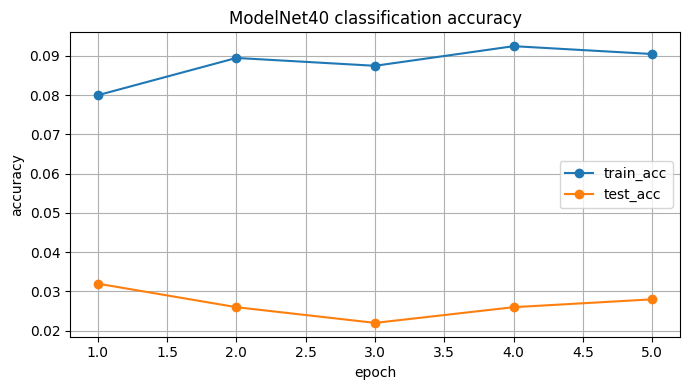

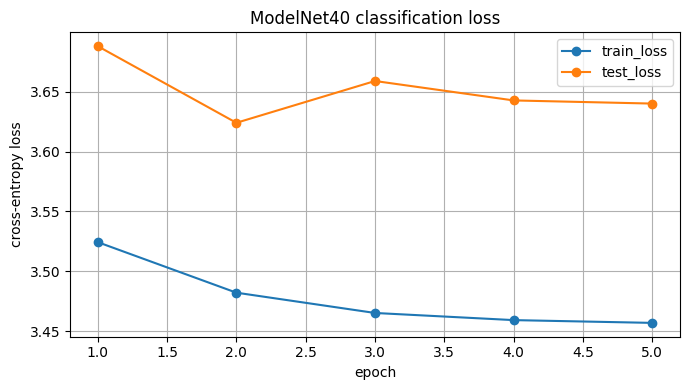


## Выводы

Была обучена простая sparse CNN модель `minkfcnn` на датасете ModelNet40 с использованием `MinkowskiEngine`.

Из-за проблем CUDA-сборки `MinkowskiEngine` в текущем окружении Kaggle обучение выполнялось в CPU-only режиме.
Для стабильного запуска использовался robust preprocessing: mesh-модели преобразовывались в облака точек, затем
квантизовались в sparse voxel representation. Для некорректных или вырожденных OFF-моделей был добавлен fallback
на сэмплирование вершин, чтобы избежать `NaN` в вероятностях выбора треугольников.

Параметры эксперимента:
- `NUM_POINTS = 1024`
- `VOXEL_SIZE = 0.06`
- `MAX_VOXELS_PER_OBJECT = 900`
- `BATCH_SIZE = 8`
- `EPOCHS = 5`
- `MAX_TRAIN_SAMPLES = 2000`
- `MAX_TEST_SAMPLES = 500`

Лучшая accuracy на test subset: **0.0320** на эпохе **1**.  
Итоговая accuracy на последней эпохе: **0.0280**.  
Итоговый test loss на последней эпохе: **3.6402**.



In [11]:
# %%
# ============================
# ONE-CELL SAFE RERUN
# ModelNet40 + MinkowskiEngine CPU-only
# ============================

import os
import math
import time
import random
import zipfile
import hashlib
import shutil
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

import MinkowskiEngine as ME

# ----------------------------
# Config
# ----------------------------

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")

WORK_DIR = Path("/kaggle/working/minkfcnn_modelnet40_cpu_safe")
WORK_DIR.mkdir(parents=True, exist_ok=True)


NUM_POINTS = 1024
VOXEL_SIZE = 0.06
MAX_VOXELS_PER_OBJECT = 900

BATCH_SIZE = 8
NUM_WORKERS = 0
EPOCHS = 5
LR = 1e-3
WEIGHT_DECAY = 1e-4


MAX_TRAIN_SAMPLES = 2000
MAX_TEST_SAMPLES = 500

CACHE_DIR = WORK_DIR / f"surface_cache_{NUM_POINTS}_safe"

if CACHE_DIR.exists():
    shutil.rmtree(CACHE_DIR)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("device:", device)
print("work dir:", WORK_DIR)
print("cache dir:", CACHE_DIR)
print("torch:", torch.__version__)
print("MinkowskiEngine:", ME.__file__)

# ----------------------------
# Locate / download ModelNet40
# ----------------------------

def is_modelnet40_root(path: Path) -> bool:
    path = Path(path)
    if not path.exists() or not path.is_dir():
        return False
    class_dirs = [
        d for d in path.iterdir()
        if d.is_dir() and (d / "train").exists() and (d / "test").exists()
    ]
    return len(class_dirs) >= 40 and (path / "airplane").exists()


def find_existing_modelnet40_root() -> Path | None:
    candidates = [
        Path("/kaggle/working/ModelNet40"),
        Path("/kaggle/input/modelnet40/ModelNet40"),
        Path("/kaggle/input/modelnet40"),
        Path("/kaggle/input/modelnet40-princeton-3d-object-dataset/ModelNet40"),
        Path("/kaggle/input/modelnet40-princeton-3d-object-dataset"),
    ]

    for candidate in candidates:
        if is_modelnet40_root(candidate):
            return candidate

    input_root = Path("/kaggle/input")
    if input_root.exists():
        for airplane_dir in input_root.rglob("airplane"):
            root = airplane_dir.parent
            if is_modelnet40_root(root):
                return root

    return None


def download_modelnet40() -> Path:
    dst_root = Path("/kaggle/working/ModelNet40")
    if is_modelnet40_root(dst_root):
        return dst_root

    zip_path = Path("/kaggle/working/ModelNet40.zip")
    urls = [
        "http://modelnet.cs.princeton.edu/ModelNet40.zip",
        "https://modelnet.cs.princeton.edu/ModelNet40.zip",
    ]

    if not zip_path.exists():
        last_error = None
        for url in urls:
            try:
                print(f"Downloading ModelNet40 from {url}")
                urllib.request.urlretrieve(url, zip_path)
                break
            except Exception as error:
                last_error = error
                print(f"Failed: {error}")

        if not zip_path.exists():
            raise RuntimeError(
                "Не удалось скачать ModelNet40. "
                "Включите Internet в Kaggle или добавьте ModelNet40 как Kaggle Dataset."
            ) from last_error

    print("Extracting ModelNet40.zip ...")
    with zipfile.ZipFile(zip_path, "r") as archive:
        archive.extractall("/kaggle/working")

    if not is_modelnet40_root(dst_root):
        raise RuntimeError("Архив распакован, но папка /kaggle/working/ModelNet40 не найдена.")

    return dst_root


MODELNET_ROOT = find_existing_modelnet40_root()
if MODELNET_ROOT is None:
    MODELNET_ROOT = download_modelnet40()

CLASSES = sorted([
    d.name for d in MODELNET_ROOT.iterdir()
    if d.is_dir() and (d / "train").exists() and (d / "test").exists()
])

print("MODELNET_ROOT:", MODELNET_ROOT)
print("num classes:", len(CLASSES))
print("first classes:", CLASSES[:8])

# ----------------------------
# Robust OFF reading and sampling
# ----------------------------

def read_off(path: Path) -> tuple[np.ndarray, np.ndarray]:
    with open(path, "r", encoding="utf-8", errors="ignore") as file:
        first = ""
        while first == "":
            first = file.readline().strip()

        if first == "OFF":
            counts = file.readline().strip()
        elif first.startswith("OFF"):
            counts = first[3:].strip()
        else:
            raise ValueError(f"Not an OFF file: {path}")

        while counts == "" or counts.startswith("#"):
            counts = file.readline().strip()

        n_vertices, n_faces, *_ = map(int, counts.split()[:3])

        vertices = []
        while len(vertices) < n_vertices:
            line = file.readline()
            if not line:
                break
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            vertices.append([float(x) for x in line.split()[:3]])

        faces = []
        for _ in range(n_faces):
            line = file.readline()
            if not line:
                break
            parts = line.strip().split()
            if not parts:
                continue

            n = int(parts[0])
            if n < 3:
                continue

            ids = [int(x) for x in parts[1:1 + n]]
            for j in range(1, n - 1):
                faces.append([ids[0], ids[j], ids[j + 1]])

    return np.asarray(vertices, dtype=np.float32), np.asarray(faces, dtype=np.int64)


def normalize_points(points: np.ndarray) -> np.ndarray:
    points = np.asarray(points, dtype=np.float64)

    if points.ndim != 2 or points.shape[1] != 3 or len(points) == 0:
        return np.zeros((1, 3), dtype=np.float32)

    finite_mask = np.isfinite(points).all(axis=1)
    points = points[finite_mask]

    if len(points) == 0:
        return np.zeros((1, 3), dtype=np.float32)

    points = points - points.mean(axis=0, keepdims=True)
    scale = np.linalg.norm(points, axis=1).max()

    if (not np.isfinite(scale)) or scale <= 1e-12:
        return np.zeros_like(points, dtype=np.float32)

    points = points / scale
    points = np.nan_to_num(points, nan=0.0, posinf=0.0, neginf=0.0)

    return points.astype(np.float32)


def sample_points_from_mesh(
    vertices: np.ndarray,
    faces: np.ndarray,
    num_points: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Safe surface sampling.
    If face areas are broken / zero / NaN / inf, falls back to vertex sampling.
    """
    vertices = np.asarray(vertices, dtype=np.float64)
    faces = np.asarray(faces, dtype=np.int64)

    if len(vertices) == 0:
        return np.zeros((num_points, 3), dtype=np.float32)

    finite_vertex_mask = np.isfinite(vertices).all(axis=1)
    vertices = vertices[finite_vertex_mask]

    if len(vertices) == 0:
        return np.zeros((num_points, 3), dtype=np.float32)

    vertices = normalize_points(vertices).astype(np.float64)

    def sample_vertices() -> np.ndarray:
        replace = len(vertices) < num_points
        idx = rng.choice(len(vertices), size=num_points, replace=replace)
        sampled_vertices = vertices[idx]
        sampled_vertices = np.nan_to_num(sampled_vertices, nan=0.0, posinf=0.0, neginf=0.0)
        return normalize_points(sampled_vertices)

    if len(faces) == 0 or faces.ndim != 2 or faces.shape[1] != 3:
        return sample_vertices()

    valid_faces = (
        (faces[:, 0] >= 0) & (faces[:, 0] < len(vertices)) &
        (faces[:, 1] >= 0) & (faces[:, 1] < len(vertices)) &
        (faces[:, 2] >= 0) & (faces[:, 2] < len(vertices))
    )
    faces = faces[valid_faces]

    if len(faces) == 0:
        return sample_vertices()

    triangles = vertices[faces]
    v0, v1, v2 = triangles[:, 0], triangles[:, 1], triangles[:, 2]

    cross = np.cross(v1 - v0, v2 - v0)
    areas = 0.5 * np.linalg.norm(cross, axis=1)

    valid_area_mask = np.isfinite(areas) & (areas > 1e-12)

    if valid_area_mask.sum() == 0:
        return sample_vertices()

    triangles = triangles[valid_area_mask]
    areas = areas[valid_area_mask].astype(np.float64)

    area_sum = areas.sum()
    if (not np.isfinite(area_sum)) or area_sum <= 1e-12:
        return sample_vertices()

    probs = areas / area_sum
    probs = np.nan_to_num(probs, nan=0.0, posinf=0.0, neginf=0.0)

    prob_sum = probs.sum()
    if (not np.isfinite(prob_sum)) or prob_sum <= 1e-12:
        return sample_vertices()

    probs = probs / prob_sum

    try:
        tri_idx = rng.choice(len(triangles), size=num_points, replace=True, p=probs)
    except ValueError:
        return sample_vertices()

    chosen = triangles[tri_idx]

    r1 = rng.random(num_points)
    r2 = rng.random(num_points)
    sqrt_r1 = np.sqrt(r1)

    sampled = (
        (1.0 - sqrt_r1)[:, None] * chosen[:, 0]
        + (sqrt_r1 * (1.0 - r2))[:, None] * chosen[:, 1]
        + (sqrt_r1 * r2)[:, None] * chosen[:, 2]
    )

    sampled = np.nan_to_num(sampled, nan=0.0, posinf=0.0, neginf=0.0)
    return normalize_points(sampled)


def augment_point_cloud(points: np.ndarray) -> np.ndarray:
    points = np.asarray(points, dtype=np.float32)
    points = np.nan_to_num(points, nan=0.0, posinf=0.0, neginf=0.0)

    theta = np.random.uniform(0.0, 2.0 * np.pi)
    cos_t, sin_t = np.cos(theta), np.sin(theta)

    rot_z = np.array(
        [[cos_t, -sin_t, 0.0],
         [sin_t,  cos_t, 0.0],
         [0.0,    0.0,   1.0]],
        dtype=np.float32,
    )

    points = points @ rot_z.T
    points = points * np.random.uniform(0.90, 1.10)
    points = points + np.random.normal(0.0, 0.005, size=points.shape).astype(np.float32)
    points = np.nan_to_num(points, nan=0.0, posinf=0.0, neginf=0.0)

    return points.astype(np.float32)

# ----------------------------
# Dataset and loaders
# ----------------------------

class ModelNet40OFF(Dataset):
    def __init__(
        self,
        root: Path,
        split: str,
        classes: list[str],
        num_points: int,
        voxel_size: float,
        max_voxels: int,
        augment: bool,
        cache_dir: Path,
        max_samples: int | None = None,
    ):
        assert split in {"train", "test"}

        self.root = Path(root)
        self.split = split
        self.classes = classes
        self.class_to_idx = {name: idx for idx, name in enumerate(classes)}
        self.num_points = num_points
        self.voxel_size = voxel_size
        self.max_voxels = max_voxels
        self.augment = augment
        self.cache_dir = Path(cache_dir)

        samples = []
        for class_name in self.classes:
            class_dir = self.root / class_name / split
            for path in sorted(class_dir.glob("*.off")):
                samples.append((path, self.class_to_idx[class_name]))

        if max_samples is not None:
            rng = random.Random(SEED)
            rng.shuffle(samples)
            samples = samples[:max_samples]

        self.samples = samples

    def __len__(self) -> int:
        return len(self.samples)

    def _cache_path(self, off_path: Path) -> Path:
        rel = off_path.relative_to(self.root).with_suffix(".npz")
        return self.cache_dir / rel

    def _load_or_create_points(self, off_path: Path) -> np.ndarray:
        cache_path = self._cache_path(off_path)

        if cache_path.exists():
            try:
                points = np.load(cache_path)["points"].astype(np.float32)
                if points.shape == (self.num_points, 3) and np.isfinite(points).all():
                    return points
                cache_path.unlink(missing_ok=True)
            except Exception:
                cache_path.unlink(missing_ok=True)

        try:
            vertices, faces = read_off(off_path)
            seed = int(hashlib.md5(str(off_path).encode("utf-8")).hexdigest()[:8], 16)
            rng = np.random.default_rng(seed)
            points = sample_points_from_mesh(vertices, faces, self.num_points, rng)
        except Exception as error:
            print(f"[WARN] failed to read/sample {off_path}: {repr(error)}")
            points = np.zeros((self.num_points, 3), dtype=np.float32)

        if points.shape != (self.num_points, 3):
            rng = np.random.default_rng(SEED)
            replace = len(points) < self.num_points
            idx = rng.choice(len(points), size=self.num_points, replace=replace)
            points = points[idx]

        points = np.nan_to_num(points, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

        cache_path.parent.mkdir(parents=True, exist_ok=True)
        np.savez_compressed(cache_path, points=points)

        return points

    def __getitem__(self, index: int):
        off_path, label = self.samples[index]
        points = self._load_or_create_points(off_path).copy()

        if self.augment:
            points = augment_point_cloud(points)

        coords = np.floor(points / self.voxel_size).astype(np.int32)
        coords = np.nan_to_num(coords, nan=0, posinf=0, neginf=0).astype(np.int32)
        coords = coords - coords.min(axis=0, keepdims=True)

        coords = np.unique(coords, axis=0)

        if len(coords) == 0:
            coords = np.zeros((1, 3), dtype=np.int32)

        if len(coords) > self.max_voxels:
            selected = np.random.choice(len(coords), self.max_voxels, replace=False)
            coords = coords[selected]

        feats = np.ones((len(coords), 1), dtype=np.float32)

        return (
            torch.from_numpy(coords).int(),
            torch.from_numpy(feats).float(),
            torch.tensor(label, dtype=torch.long),
        )


def sparse_collate(batch):
    coords, feats, labels = zip(*batch)
    batched_coords = ME.utils.batched_coordinates(coords, dtype=torch.int32)
    batched_feats = torch.cat(feats, dim=0).float()
    labels = torch.stack(labels, dim=0).long()
    return batched_coords, batched_feats, labels


train_dataset = ModelNet40OFF(
    root=MODELNET_ROOT,
    split="train",
    classes=CLASSES,
    num_points=NUM_POINTS,
    voxel_size=VOXEL_SIZE,
    max_voxels=MAX_VOXELS_PER_OBJECT,
    augment=True,
    cache_dir=CACHE_DIR,
    max_samples=MAX_TRAIN_SAMPLES,
)

test_dataset = ModelNet40OFF(
    root=MODELNET_ROOT,
    split="test",
    classes=CLASSES,
    num_points=NUM_POINTS,
    voxel_size=VOXEL_SIZE,
    max_voxels=MAX_VOXELS_PER_OBJECT,
    augment=False,
    cache_dir=CACHE_DIR,
    max_samples=MAX_TEST_SAMPLES,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=sparse_collate,
    pin_memory=False,
    drop_last=True,
    persistent_workers=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=sparse_collate,
    pin_memory=False,
    drop_last=False,
    persistent_workers=False,
)

print("train objects:", len(train_dataset))
print("test objects:", len(test_dataset))
print("classes:", len(CLASSES))

coords, feats, labels = next(iter(train_loader))
print("batch coords:", coords.shape, coords.dtype)
print("batch feats:", feats.shape, feats.dtype)
print("batch labels:", labels.shape, labels[:8].tolist())

# ----------------------------
# Model
# ----------------------------

class MinkFCNN(nn.Module):
    def __init__(self, in_channels: int = 1, num_classes: int = 40, dimension: int = 3):
        super().__init__()
        D = dimension

        self.backbone = nn.Sequential(
            ME.MinkowskiConvolution(in_channels, 32, kernel_size=3, stride=1, bias=False, dimension=D),
            ME.MinkowskiBatchNorm(32),
            ME.MinkowskiReLU(inplace=True),
            ME.MinkowskiMaxPooling(kernel_size=2, stride=2, dimension=D),

            ME.MinkowskiConvolution(32, 64, kernel_size=3, stride=1, bias=False, dimension=D),
            ME.MinkowskiBatchNorm(64),
            ME.MinkowskiReLU(inplace=True),
            ME.MinkowskiMaxPooling(kernel_size=2, stride=2, dimension=D),

            ME.MinkowskiConvolution(64, 128, kernel_size=3, stride=1, bias=False, dimension=D),
            ME.MinkowskiBatchNorm(128),
            ME.MinkowskiReLU(inplace=True),
        )

        self.pool = ME.MinkowskiGlobalAvgPooling()
        self.classifier = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.30),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: ME.SparseTensor) -> torch.Tensor:
        x = self.backbone(x)
        x = self.pool(x)
        return self.classifier(x.F)


model = MinkFCNN(in_channels=1, num_classes=len(CLASSES), dimension=3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print("trainable params:", f"{num_params:,}")

# ----------------------------
# Training
# ----------------------------

def make_sparse_tensor(coords: torch.Tensor, feats: torch.Tensor) -> ME.SparseTensor:
    return ME.SparseTensor(
        features=feats.float(),
        coordinates=coords.int(),
    )


def clear_me_cache():
    try:
        if hasattr(ME, "clear_global_coordinate_manager"):
            ME.clear_global_coordinate_manager()
    except Exception:
        pass


def run_epoch(loader, train: bool, epoch: int):
    model.train(train)

    total_loss = 0.0
    total_correct = 0
    total_objects = 0

    desc = f"{'train' if train else 'test '} epoch {epoch:02d}"
    pbar = tqdm(loader, desc=desc, leave=False)

    for coords, feats, labels in pbar:
        labels = labels.to(device)

        with torch.set_grad_enabled(train):
            if train:
                optimizer.zero_grad(set_to_none=True)

            sparse_input = make_sparse_tensor(coords, feats)
            logits = model(sparse_input)
            loss = criterion(logits, labels)

            if train:
                loss.backward()
                optimizer.step()

        batch_size = labels.size(0)
        preds = logits.argmax(dim=1)

        total_loss += loss.item() * batch_size
        total_correct += (preds == labels).sum().item()
        total_objects += batch_size

        pbar.set_postfix({
            "loss": total_loss / max(total_objects, 1),
            "acc": total_correct / max(total_objects, 1),
        })

        del sparse_input, logits, loss
        clear_me_cache()

    return {
        "loss": total_loss / max(total_objects, 1),
        "acc": total_correct / max(total_objects, 1),
    }


logs = []
best_test_acc = -1.0
best_ckpt_path = WORK_DIR / "minkfcnn_modelnet40_best.pth"
log_path = WORK_DIR / "minkfcnn_modelnet40_training_log.csv"

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()

    train_metrics = run_epoch(train_loader, train=True, epoch=epoch)
    test_metrics = run_epoch(test_loader, train=False, epoch=epoch)
    scheduler.step()

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_acc": train_metrics["acc"],
        "test_loss": test_metrics["loss"],
        "test_acc": test_metrics["acc"],
        "lr": optimizer.param_groups[0]["lr"],
        "seconds": time.time() - start_time,
        "num_points": NUM_POINTS,
        "voxel_size": VOXEL_SIZE,
        "max_train_samples": MAX_TRAIN_SAMPLES,
        "max_test_samples": MAX_TEST_SAMPLES,
    }
    logs.append(row)

    log_df = pd.DataFrame(logs)
    log_df.to_csv(log_path, index=False)

    if row["test_acc"] > best_test_acc:
        best_test_acc = row["test_acc"]
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "classes": CLASSES,
                "config": {
                    "num_points": NUM_POINTS,
                    "voxel_size": VOXEL_SIZE,
                    "max_voxels_per_object": MAX_VOXELS_PER_OBJECT,
                    "batch_size": BATCH_SIZE,
                    "epochs": EPOCHS,
                    "lr": LR,
                    "weight_decay": WEIGHT_DECAY,
                    "max_train_samples": MAX_TRAIN_SAMPLES,
                    "max_test_samples": MAX_TEST_SAMPLES,
                    "device": str(device),
                },
                "best_test_acc": best_test_acc,
            },
            best_ckpt_path,
        )

    print(
        f"epoch {epoch:02d}/{EPOCHS} | "
        f"train loss {row['train_loss']:.4f}, train acc {row['train_acc']:.4f} | "
        f"test loss {row['test_loss']:.4f}, test acc {row['test_acc']:.4f} | "
        f"best test acc {best_test_acc:.4f} | "
        f"{row['seconds']:.1f}s"
    )

print("saved log:", log_path)
print("saved best checkpoint:", best_ckpt_path)

# ----------------------------
# Plots and conclusion
# ----------------------------

log_df = pd.read_csv(log_path)
display(log_df)

plt.figure(figsize=(7, 4))
plt.plot(log_df["epoch"], log_df["train_acc"], marker="o", label="train_acc")
plt.plot(log_df["epoch"], log_df["test_acc"], marker="o", label="test_acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("ModelNet40 classification accuracy")
plt.grid(True)
plt.legend()
plt.tight_layout()
acc_plot_path = WORK_DIR / "accuracy_plot.png"
plt.savefig(acc_plot_path, dpi=160, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(log_df["epoch"], log_df["train_loss"], marker="o", label="train_loss")
plt.plot(log_df["epoch"], log_df["test_loss"], marker="o", label="test_loss")
plt.xlabel("epoch")
plt.ylabel("cross-entropy loss")
plt.title("ModelNet40 classification loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
loss_plot_path = WORK_DIR / "loss_plot.png"
plt.savefig(loss_plot_path, dpi=160, bbox_inches="tight")
plt.show()

best_row = log_df.loc[log_df["test_acc"].idxmax()]

display(Markdown(f"""
## Выводы

Была обучена простая sparse CNN модель `minkfcnn` на датасете ModelNet40 с использованием `MinkowskiEngine`.

Из-за проблем CUDA-сборки `MinkowskiEngine` в текущем окружении Kaggle обучение выполнялось в CPU-only режиме.
Для стабильного запуска использовался robust preprocessing: mesh-модели преобразовывались в облака точек, затем
квантизовались в sparse voxel representation. Для некорректных или вырожденных OFF-моделей был добавлен fallback
на сэмплирование вершин, чтобы избежать `NaN` в вероятностях выбора треугольников.

Параметры эксперимента:
- `NUM_POINTS = {NUM_POINTS}`
- `VOXEL_SIZE = {VOXEL_SIZE}`
- `MAX_VOXELS_PER_OBJECT = {MAX_VOXELS_PER_OBJECT}`
- `BATCH_SIZE = {BATCH_SIZE}`
- `EPOCHS = {EPOCHS}`
- `MAX_TRAIN_SAMPLES = {MAX_TRAIN_SAMPLES}`
- `MAX_TEST_SAMPLES = {MAX_TEST_SAMPLES}`

Лучшая accuracy на test subset: **{best_row["test_acc"]:.4f}** на эпохе **{int(best_row["epoch"])}**.  
Итоговая accuracy на последней эпохе: **{log_df.iloc[-1]["test_acc"]:.4f}**.  
Итоговый test loss на последней эпохе: **{log_df.iloc[-1]["test_loss"]:.4f}**.

"""))

# Основной пайплайн задания был успешно реализован:
#
# 1. датасет ModelNet40 был загружен;
# 2. mesh-модели были преобразованы в облака точек;
# 3. точки были квантизованы в sparse voxel representation;
# 4. модель `minkfcnn` была обучена с использованием `MinkowskiEngine`;
# 5. были сохранены логи обучения, checkpoint лучшей модели и графики loss/accuracy.

К сожалению из-за ограничений по доступному компьюту на данный моментб запустить локально эксперимент на гпу не является возможным.
Полученное качество оказалось низким и близким к случайному угадыванию для 40 классов
(`1 / 40 = 0.025`). Это объясняется ограниченным CPU-only экспериментом, малым числом эпох,
уменьшенным подмножеством данных, грубой voxel-квантизацией и простой архитектурой модели.